数据打标签

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve,average_precision_score
)

import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['STKaiti']  # 设置中文字体为楷体
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel("campusBicyclesharingdataset.xlsx")

binary_cols = ['A', 'B', 'E1', 'E2', 'E3', 'E4']
df[binary_cols] = df[binary_cols].replace({'高': 1, '低': 0})

# 特征标签
X = df[['F1', 'F2', 'F3', 'F4']]
y = df['B']

# 训练集划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 标准化（用于PCA）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

C:\Users\17520\AppData\Local\Temp\ipykernel_26588\4275542935.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'高': 1, '低': 0})


6. 单目标分类与模型比较：分别建立LDA,QDA,LR,NB模型

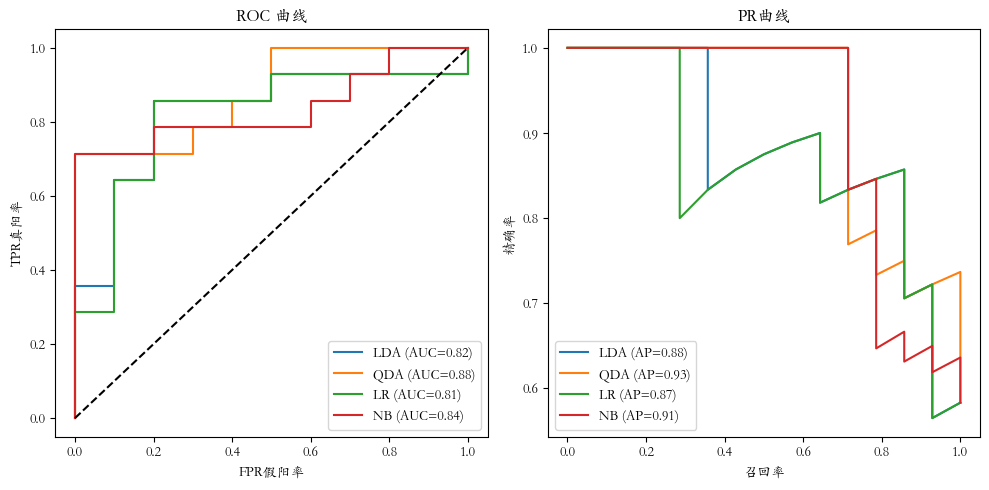

      准确率       精确率       召回率        F1
LDA  0.75  0.722222  0.928571  0.812500
QDA  0.75  0.785714  0.785714  0.785714
LR   0.75  0.722222  0.928571  0.812500
NB   0.75  0.785714  0.785714  0.785714


In [27]:
models = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'LR': LogisticRegression(max_iter=1000),
    'NB': GaussianNB()
}

results = {}

plt.figure(figsize=(10, 5))

# ROC 曲线
plt.subplot(1, 2, 1)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = [acc, prec, rec, f1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC 曲线")
plt.xlabel("FPR假阳率")
plt.ylabel("TPR真阳率")
plt.legend()

# PR 曲线
plt.subplot(1, 2, 2)

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    ap = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision,
             label=f"{name} (AP={ap:.2f})")

plt.title("PR曲线")
plt.xlabel("召回率")
plt.ylabel("精确率")
plt.legend()

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results, index=['准确率', '精确率', '召回率', 'F1']).T
print(results_df)

7. 降维分析：将主成分作为新的特征进行预测

解释方差比: [0.58138204 0.26088912]
         F1       F2        F3        F4
0 -0.537246  0.60343 -0.258324 -0.529629
1 -0.442966  0.16659  0.852092  0.223536


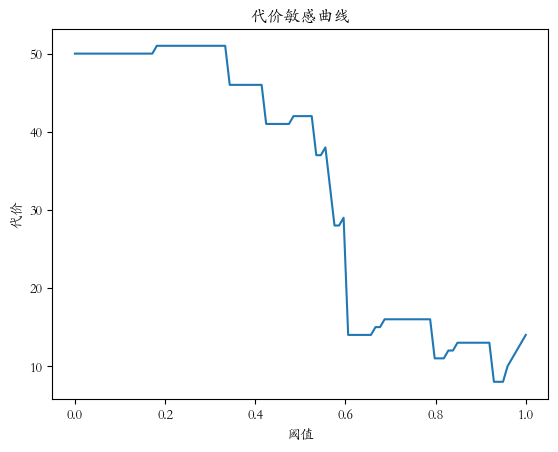

最优阈值 0.9292929292929294


In [ ]:
# PCA
print("PCA降维前的特征维度:", X_train_scaled.shape[1])  
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("解释方差比:", pca.explained_variance_ratio_)
print( pd.DataFrame(pca.components_, columns=X.columns))

# 用PCA建立的模型
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_pca, y_train)

y_prob = log_model.predict_proba(X_test_pca)[:, 1]

# 代价敏感曲线
thresholds = np.linspace(0, 1, 100)
costs = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    FP = np.sum((y_pred_t == 1) & (y_test == 0))
    FN = np.sum((y_pred_t == 0) & (y_test == 1))
    
    cost = FP * 5 + FN * 1
    costs.append(cost)

plt.figure()
plt.plot(thresholds, costs)
plt.xlabel("阈值")
plt.ylabel("代价")
plt.title("代价敏感曲线")
plt.show()

# 最优阈值
best_threshold = thresholds[np.argmin(costs)]
print("最优阈值", best_threshold)


7. 运营建议

结合前述所有任务给出分析结论，撰写一份简洁的运营优化建议报告，指出当前共享单车服务体系中的关键瓶颈，并提出数据驱动的合理化改进经营的措施。

共享单车服务体系分析结论与运营优化建议
通过对 A-F 各项指标的描述性统计、相关性分析以及随机森林模型的训练，我们组对当前校园共享单车服务体系的运行状况进行如下总结，并提出相应优化建议。

(1)核心分析结论

首先，当前系统的主要瓶颈体现在“寻车效率”与“时空错配”上。前面的描述性统计表明，寻车时间（F2）的波动较大，且与车辆分布合理性（A）呈显著负相关关系。这说明，用户面临的问题并非单纯的车辆供给不足，而更多来源于车辆分布不均或定位精度不足，从而增加了实际寻车成本。

其次，车辆周转率（F1）与分布合理性之间存在较强的正相关关系。车辆配置越合理，其使用频率越高；反之，部分区域存在车辆长期滞留的现象，降低了整体运营效率。所以仅依靠增加投放量难以提升系统效率，更为重要的是合理配置。

再次，从服务质量角度来看，动态调度能力与设备运行状态（E1–E4）虽在模型中的直接权重相对有限，但其对用户体验具有基本性的影响。在故障率较高的区域，用户评价（A）和使用表现均明显较差，说明硬件可靠性是保障服务稳定运行的必要条件。

(2)数据驱动的改进建议

基于上述分析，提出以下优化方向：

第一，优化热点区域的动态调度机制。结合模型对高需求时段与空间分布的预测结果，可以在早晚高峰前进行预调度，重点缩短用户平均寻车时间（F2），提升车辆可达性。

第二，建立低周转车辆的识别与引导机制。对于长期处于低周转状态（F1偏低）的车辆，可通过系统标记并结合激励措施（如调度奖励或路径补贴），引导其向需求集中区域回流，从而减少无效库存。

第三，完善设备维护与巡检体系。根据故障发生的空间分布特征，对高风险区域实施更高频次的巡检与维护，以降低设备故障对整体服务质量的影响。

第四，提升平台端的定位与引导能力。针对寻车时间较长的问题，可优化定位精度与路径引导功能，减少用户因定位偏差带来的额外时间成本，从而改善整体出行体验。

（3）总结

总体来看，当前共享单车系统的优化重点不在于单纯扩大车辆规模，而在于提升既有资源的配置效率。通过缩短寻车时间、提高车辆周转率并强化设备可靠性，可以在不增加大量投入的情况下显著改善服务质量，实现更高效的运营模式。